# Train ML Models

This notebook train the ML models in order to create the constraints for the optimization problem. The models are trained using the data generated in the DataGenerationROBIN module.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary
from torchview import draw_graph

from models.dnn import FeedForwardNN

# Allow pandas to display all columns
pd.set_option("display.max_columns", None)

In [3]:
def smape(y_true, y_pred, epsilon=1e-8):
    """
    Calcula el Symmetric Mean Absolute Percentage Error (sMAPE)
    entre los valores reales y predichos.

    Parámetros:
    - y_true: array-like, valores reales
    - y_pred: array-like, valores predichos
    - epsilon: valor pequeño para evitar divisiones por cero

    Retorna:
    - smape: float, error porcentual simétrico medio
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape = np.mean(np.abs(y_pred - y_true) / (denominator + epsilon)) * 100
    return smape


## Load the dataset and preprocess it

In [4]:
path_data = "../DataGenerationROBIN/data/MAD-BCN/aggregated/MAD-BCN_2025.csv"

data = pd.read_csv(path_data, sep=",")

y_col = "passengers"  # The demand data
y = data[y_col]
X = data.drop(columns=[y_col], axis=1, inplace=False)
X_processed = X.copy()

data.columns

Index(['service_id', 'train_type', 'capacity', 'train_model', 'year', 'month',
       'day_of_week', 'departure_time', 'duration', 'price', 'passengers',
       'time_distance_competitor_-2', 'price_competitor_-2',
       'train_type_competitor_-2', 'duration_competitor_-2',
       'time_distance_competitor_-1', 'price_competitor_-1',
       'train_type_competitor_-1', 'duration_competitor_-1',
       'time_distance_competitor_1', 'price_competitor_1',
       'train_type_competitor_1', 'duration_competitor_1',
       'time_distance_competitor_2', 'price_competitor_2',
       'train_type_competitor_2', 'duration_competitor_2'],
      dtype='object')

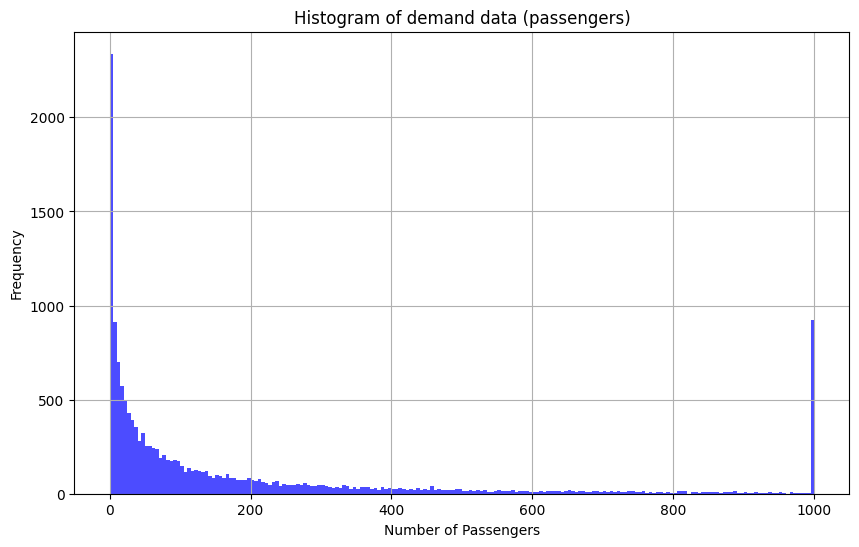

In [48]:
## Clipping the data to handle outliers

# Clip the demand data to handle outliers
MIN_VALUE = 0  # Define a minimum value for clipping
MAX_VALUE = 1000  # Define a maximum value for clipping
y = np.clip(y, None, MAX_VALUE)

# Pre-process y to remove the impact of large outliers using a log transformation
# y = np.log1p(y)  # log(1 + y) to handle zero values

# Plot the histogram of the demand data
plt.figure(figsize=(10, 6))
plt.hist(y, bins=200, color="blue", alpha=0.7)
plt.title("Histogram of demand data (passengers)")
plt.xlabel("Number of Passengers")
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [6]:
## Process temporal features

# Create new column 'weekend' based on 'day_of_week'
#X_processed["weekend"] = (X_processed["day_of_week"] >= 5).astype(int)


# Apply sine/cosine transformation to the columns: 'month', 'day_of_week', 'departure_time'
def sine_cosine_transform(df, col, period, drop=False):
    df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period)
    df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)
    if drop:
        df.drop(columns=[col], inplace=True)
    return df


X_processed = sine_cosine_transform(X_processed, "month", 12, drop=True)
X_processed = sine_cosine_transform(X_processed, "day_of_week", 7, drop=True)
X_processed = sine_cosine_transform(X_processed, "departure_time", 24, drop=True)


In [7]:
## Process categorical features

# Apply one-hot encoding to the columns: 'train_type' and train_type_competitor_i
cols_to_encode = ["train_type"] + [
    f"train_type_competitor_{i}" for i in range(-2, 3) if i != 0
]

# Use pandas get_dummies to one-hot encode the specified columns
X_processed = pd.get_dummies(
    X_processed, columns=cols_to_encode, drop_first=False, dtype=int
)

In [8]:
## Remove unused columns
X_processed.drop(
    columns=["service_id", "capacity", "train_model", "year"], inplace=True
)

In [9]:
## Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=2025, shuffle=False)

#X_train = X_processed.copy()
#X_test = X_processed.copy()
#y_train = y.copy()
#y_test = y.copy()

print(f"Number of training samples: {len(X_train)}, Number of testing samples: {len(X_test)}")

Number of training samples: 12056, Number of testing samples: 3014


In [10]:
## Scale the features

scaled_feat = (
    ["duration", "price"]
    + [f"duration_competitor_{i}" for i in range(-2, 3) if i != 0]
    + [f"time_distance_competitor_{i}" for i in range(-2, 3) if i != 0]
    + [f"price_competitor_{i}" for i in range(-2, 3) if i != 0]
)

# Scale the features
feat_scaler = StandardScaler()
X_train[scaled_feat] = feat_scaler.fit_transform(X_train[scaled_feat])
X_test[scaled_feat] = feat_scaler.transform(X_test[scaled_feat])

# Scale the target variable
target_scaler = StandardScaler()
y_train = pd.DataFrame(target_scaler.fit_transform(y_train.values.reshape(-1, 1)), columns = [y.name])
y_test = pd.DataFrame(target_scaler.transform(y_test.values.reshape(-1, 1)), columns = [y.name])


In [11]:
## Describe the training data
X_train.describe()

,duration,price,time_distance_competitor_-2,price_competitor_-2,duration_competitor_-2,time_distance_competitor_-1,price_competitor_-1,duration_competitor_-1,time_distance_competitor_1,price_competitor_1,duration_competitor_1,time_distance_competitor_2,price_competitor_2,duration_competitor_2,month_sin,month_cos,day_of_week_sin,day_of_week_cos,departure_time_sin,departure_time_cos,train_type_AVE,train_type_AVLO,train_type_IRYO,train_type_OUIGO,train_type_competitor_-2_AVE,train_type_competitor_-2_AVLO,train_type_competitor_-2_IRYO,train_type_competitor_-2_OUIGO,train_type_competitor_-1_AVE,train_type_competitor_-1_AVLO,train_type_competitor_-1_IRYO,train_type_competitor_-1_OUIGO,train_type_competitor_1_AVE,train_type_competitor_1_AVLO,train_type_competitor_1_IRYO,train_type_competitor_1_OUIGO,train_type_competitor_2_AVE,train_type_competitor_2_AVLO,train_type_competitor_2_IRYO,train_type_competitor_2_OUIGO
count,1.205600e+04,1.205600e+04,1.205600e+04,1.205600e+04,1.205600e+04,1.205600e+04,1.205600e+04,1.205600e+04,1.205600e+04,1.205600e+04,1.205600e+04,1.205600e+04,1.205600e+04,1.205600e+04,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000,12056.000000
mean,1.505837e-16,3.394763e-16,-2.342740e-17,-1.267142e-16,9.331178e-16,8.324831e-18,-2.805394e-16,6.653971e-16,-5.540064e-17,-2.487135e-16,3.889832e-17,9.201517e-17,-1.773999e-16,4.448259e-16,0.079347,-0.217937,0.071550,0.010439,-0.185908,-0.346875,0.466987,0.107332,0.307979,0.117701,0.466904,0.107415,0.307979,0.117701,0.463504,0.107332,0.311463,0.117701,0.466987,0.107332,0.307979,0.117701,0.470388,0.103849,0.308062,0.117701
std,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,0.747974,0.621950,0.687943,0.722211,0.756832,0.521911,0.498930,0.309548,0.461677,0.322267,0.498924,0.309653,0.461677,0.322267,0.498687,0.309548,0.463111,0.322267,0.498930,0.309548,0.461677,0.322267,0.499143,0.305077,0.461712,0.322267
min,-1.086468e+00,-1.785989e+00,-4.489436e+00,-1.786049e+00,-1.087715e+00,-6.356188e+00,-1.786292e+00,-1.086737e+00,-2.821370e-01,-1.787534e+00,-1.086473e+00,-4.111065e-01,-1.789929e+00,-1.087857e+00,-1.000000,-1.000000,-0.974928,-0.900969,-0.999914,-0.995312,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-1.086468e+00,-7.178433e-01,1.334296e-01,-7.195031e-01,-1.087715e+00,9.386529e-02,-7.178152e-01,-1.086737e+00,-2.776637e-01,-7.163098e-01,-1.086473e+00,-3.007937e-01,-7.181797e-01,-1.087857e+00,-0.866025,-0.866025,-0.433884,-0.900969,-0.916712,-0.801254,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-7.481132e-02,-1.806189e-01,2.470792e-01,-1.835063e-01,-7.192644e-02,1.609602e-01,-1.804780e-01,-7.079673e-02,-1.613592e-01,-1.780110e-01,-7.489500e-02,-2.473087e-01,-1.776671e-01,-7.177314e-02,0.500000,-0.500000,0.000000,-0.222521,-0.544639,-0.370557,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.972949e-01,4.858166e-01,3.005614e-01,4.932997e-01,4.021084e-01,2.772579e-01,4.855470e-01,4.033088e-01,-9.426036e-02,4.799801e-01,3.971745e-01,-1.336531e-01,4.777361e-01,4.023993e-01,0.866025,0.500000,0.781831,0.623490,0.619094,-0.052336,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.0

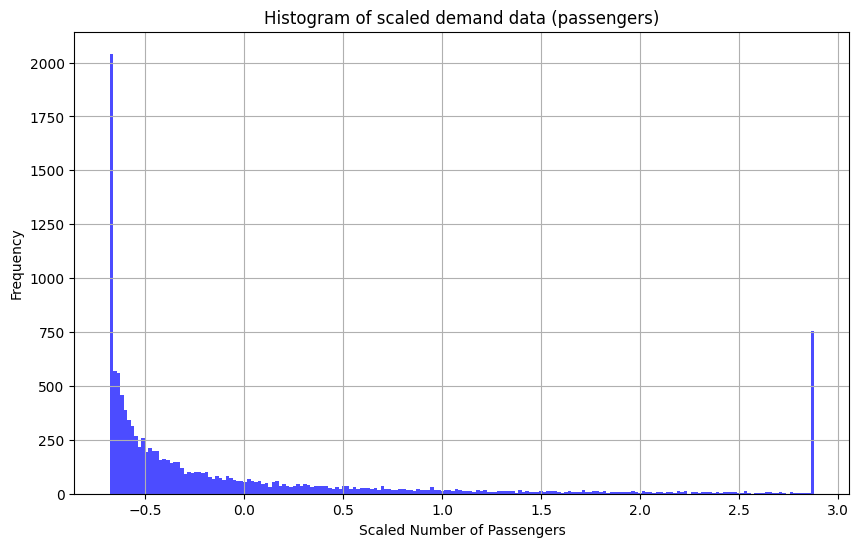

In [195]:
# Plot the histogram of the target variable after scaling
plt.figure(figsize=(10, 6))
plt.hist(y_train, bins=200, color="blue", alpha=0.7)
plt.title("Histogram of scaled demand data (passengers)")
plt.xlabel("Scaled Number of Passengers")
plt.ylabel("Frequency")
plt.grid()
plt.show()

## Train a Feedforward Neural Network

In [265]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

# If y is a 1D vector, we need to add an extra dimension
if y_train_tensor.ndim == 1:
    y_train_tensor = y_train_tensor.unsqueeze(1)

# DataLoader for training data
training_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(training_dataset, batch_size=128, shuffle=True)

In [332]:
input_size = X_train_tensor.shape[1]
output_size = 1
#hidden_layers = [128, 64, 32]
hidden_layers = [64, 32]
drop = 0.2

ffnn_model = FeedForwardNN(input_size, output_size, hidden_layers, drop)

print(summary(ffnn_model, input_size=(input_size,)))

# graph = draw_graph(
#     model = ffnn_model,
#     expand_nested = True,
#     input_size = (128,input_size),
#     graph_name = 'FeedForwardNN'
# )
# graph.visual_graph


Layer (type:depth-idx)                   Param #
├─ModuleList: 1-1                        --
|    └─Linear: 2-1                       2,624
|    └─Linear: 2-2                       2,080
├─Linear: 1-2                            33
├─ModuleList: 1-3                        --
|    └─Dropout: 2-3                      --
|    └─Dropout: 2-4                      --
Total params: 4,737
Trainable params: 4,737
Non-trainable params: 0
Layer (type:depth-idx)                   Param #
├─ModuleList: 1-1                        --
|    └─Linear: 2-1                       2,624
|    └─Linear: 2-2                       2,080
├─Linear: 1-2                            33
├─ModuleList: 1-3                        --
|    └─Dropout: 2-3                      --
|    └─Dropout: 2-4                      --
Total params: 4,737
Trainable params: 4,737
Non-trainable params: 0


In [333]:
class QuantileLoss(nn.Module):
    def __init__(self, quantile):
        super().__init__()
        self.q = quantile

    def forward(self, y_pred, y_true):
        e = y_true - y_pred
        return torch.mean(torch.maximum(self.q * e, (self.q - 1) * e))


class LogCoshLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        loss = torch.log(torch.cosh(y_pred - y_true))
        return torch.mean(loss)


# Función de pérdida y optimizador
# criterion = nn.MSELoss()
criterion = nn.L1Loss()
# criterion = nn.HuberLoss(delta=1)
# criterion = QuantileLoss(quantile=0.3)
# criterion = LogCoshLoss()
optimizer = optim.Adam(ffnn_model.parameters(), lr=1e-3, weight_decay=1e-5)

# Scheduler: reduce el LR si la val_loss no mejora tras 'patience' épocas
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                 factor=0.9, patience=10, 
                                                 verbose=True)


# Entrenamiento del modelo
loss_history = []
r2_history = []
mape_history = []

n_epochs = 1000
for epoch in range(n_epochs):
    epoch_loss = 0.0
    y_true_epoch = []
    y_pred_epoch = []

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = ffnn_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        y_true_epoch.extend(batch_y.detach().numpy())
        y_pred_epoch.extend(outputs.detach().numpy())

    # Convert the lists to numpy arrays for metric calculations
    y_true_epoch = np.array(y_true_epoch).flatten()
    y_pred_epoch = np.array(y_pred_epoch).flatten()

    avg_loss = epoch_loss / len(train_loader)
    r2 = r2_score(y_true_epoch, y_pred_epoch)
    mape = smape(y_true_epoch, y_pred_epoch)

    loss_history.append(avg_loss)
    r2_history.append(r2)
    mape_history.append(mape)

    # Update the learning rate scheduler
    scheduler.step(avg_loss)

    print(
        f"Epoch {epoch + 1}/{n_epochs} - Loss: {avg_loss:.4f} - R²: {r2:.4f} - sMAPE: {mape:.2f} - LR: {optimizer.param_groups[0]['lr']:.6f}"
    )


/Users/joseangel/miniforge3/envs/dcl-trainmarket/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/1000 - Loss: 0.7239 - R²: 0.2726 - sMAPE: 128.62 - LR: 0.001000
Epoch 2/1000 - Loss: 0.3803 - R²: 0.6200 - sMAPE: 75.77 - LR: 0.001000
Epoch 3/1000 - Loss: 0.2951 - R²: 0.7074 - sMAPE: 61.00 - LR: 0.001000
Epoch 4/1000 - Loss: 0.2616 - R²: 0.7377 - sMAPE: 57.12 - LR: 0.001000
Epoch 5/1000 - Loss: 0.2433 - R²: 0.7554 - sMAPE: 55.56 - LR: 0.001000
Epoch 6/1000 - Loss: 0.2326 - R²: 0.7675 - sMAPE: 53.97 - LR: 0.001000
Epoch 7/1000 - Loss: 0.2264 - R²: 0.7742 - sMAPE: 53.86 - LR: 0.001000
Epoch 8/1000 - Loss: 0.2200 - R²: 0.7790 - sMAPE: 53.36 - LR: 0.001000
Epoch 9/1000 - Loss: 0.2170 - R²: 0.7847 - sMAPE: 52.39 - LR: 0.001000
Epoch 10/1000 - Loss: 0.2094 - R²: 0.7897 - sMAPE: 52.14 - LR: 0.001000
Epoch 11/1000 - Loss: 0.2109 - R²: 0.7909 - sMAPE: 51.63 - LR: 0.001000
Epoch 12/1000 - Loss: 0.2088 - R²: 0.7922 - sMAPE: 51.64 - LR: 0.001000
Epoch 13/1000 - Loss: 0.2042 - R²: 0.7981 - sMAPE: 51.15 - LR: 0.001000
Epoch 14/1000 - Loss: 0.2010 - R²: 0.7978 - sMAPE: 50.70 - LR: 0.001000


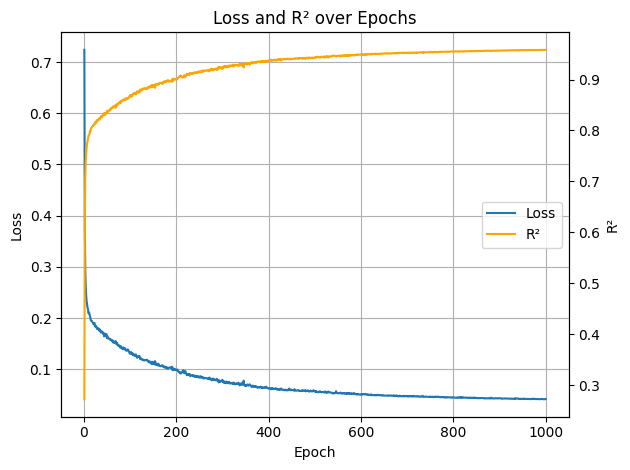

In [334]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Eje izquierdo: pérdida
ax1.plot(range(1, n_epochs + 1), loss_history, label="Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

# Eje derecho: R^2
ax2 = ax1.twinx()
ax2.plot(range(1, n_epochs + 1), r2_history, color="orange", label="R²")
ax2.set_ylabel("R²")

# Leyenda combinada
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="center right")

plt.title("Loss and R² over Epochs")
plt.tight_layout()
plt.show()

Epoch 1000/1000 - Loss: 44569.7818 - R²: 0.9255 - sMAPE: 72.03


- Clipping: Epoch 1000/1000 - Loss: 21256.4038 - R²: 0.8304 - sMAPE: 66.42


- MAE LOSS: Epoch 400/400 - Loss: 61.5474 - R²: 0.8110 - sMAPE: 54.32


- Bounded_relu + quantile loss + 2 - 128: Epoch 400/400 - Loss: 18.7776 - R²: 0.8054 - sMAPE: 52.61


- Bounded_relu + quantile loss + 128-64: Epoch 400/400 - Loss: 14.1360 - R²: 0.8679 - sMAPE: 64.43
- Bounded_relu + quantile loss + 128-64-32: Epoch 400/400 - Loss: 12.4511 - R²: 0.9043 - sMAPE: 37.02


## Evaluate the model

In [335]:
## Execute the model on the test set
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# If y is a 1D vector, we need to add an extra dimension
if y_test_tensor.ndim == 1:
    y_test_tensor = y_test_tensor.unsqueeze(1)
# DataLoader for test data
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

y_true_test = []
y_pred_test = []
for batch_X, batch_y in test_loader:
    with torch.no_grad():
        outputs = ffnn_model(batch_X)
        y_true_test.extend(batch_y.numpy())
        y_pred_test.extend(outputs.numpy())

# Convert the lists to numpy arrays for metric calculations
y_true_test = np.array(y_true_test).flatten()
y_pred_test = np.array(y_pred_test).flatten()


# y_true_test = np.expm1(y_true_test) # Inverse log transformation
# y_pred_test = np.expm1(y_pred_test) # Inverse log transformation

y_true_test = y_true_test * target_scaler.scale_[0] + target_scaler.mean_[0]
y_pred_test = y_pred_test * target_scaler.scale_[0] + target_scaler.mean_[0]

# Clip the predictions to handle outliers
y_pred_test = np.clip(y_pred_test, MIN_VALUE, MAX_VALUE)



In [336]:
print("Real demand --- Predicted")
for i in range(0, 30):
    print(f"{y_true_test[i]:.1f} --- {np.round(y_pred_test[i], 1):.1f}")

Real demand --- Predicted
12.0 --- 2.6
66.0 --- 31.4
51.0 --- 169.9
160.0 --- 139.6
74.0 --- 93.5
261.0 --- 231.4
7.0 --- 0.0
171.0 --- 107.1
362.0 --- 207.2
1.0 --- 8.7
137.0 --- 0.0
60.0 --- 19.7
248.0 --- 209.9
2.0 --- 0.0
439.0 --- 161.9
39.0 --- 26.3
630.0 --- 380.1
10.0 --- 27.5
150.0 --- 67.6
447.0 --- 210.2
12.0 --- 8.5
103.0 --- 75.2
3.0 --- 1.9
145.0 --- 164.8
18.0 --- 26.7
41.0 --- 36.0
295.0 --- 103.2
10.0 --- 10.1
13.0 --- 243.0
184.0 --- 191.5


In [337]:
print(
    "The model has failed to classify "
    f"{np.round((np.sum(np.abs(y_pred_test - y_true_test))) / np.sum(y_true_test) * 100, 2):.2f}"
    "% of the demand."
)

The model has failed to classify 37.67% of the demand.


In [338]:
# Count number of instances at a distance < d of the real value
def count_within_distance(y_true, y_pred, distance):
    n_instances = np.sum(np.abs(y_pred - y_true) < distance)
    percentage = np.round((n_instances / len(y_true)) * 100, 2)
    return n_instances, percentage

print(f"Percentage of instances with prediction within 10 of the real value: {count_within_distance(y_true_test, y_pred_test, 10)[1]}")
print(f"Percentage of instances with prediction within 25 of the real value: {count_within_distance(y_true_test, y_pred_test, 20)[1]}")
print(f"Percentage of instances with prediction within 50 of the real value: {count_within_distance(y_true_test, y_pred_test, 50)[1]}")


Percentage of instances with prediction within 10 of the real value: 31.65
Percentage of instances with prediction within 25 of the real value: 46.35
Percentage of instances with prediction within 50 of the real value: 66.09


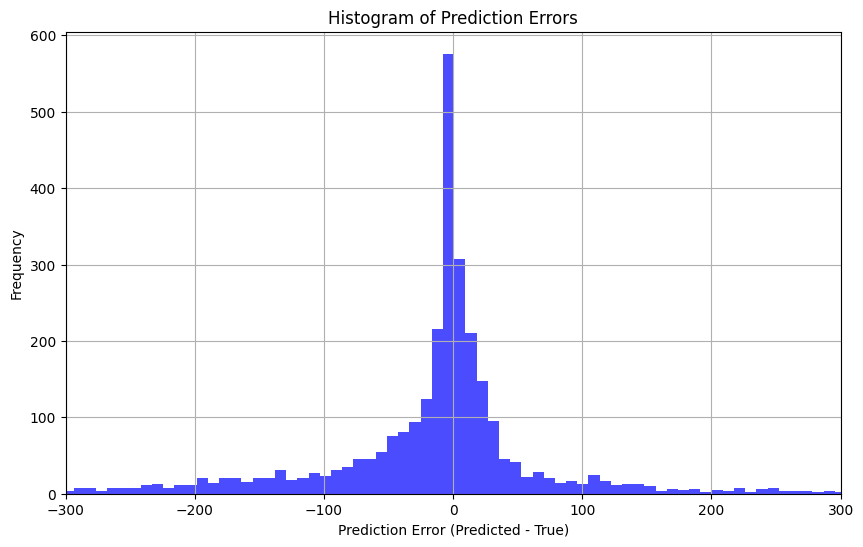

In [339]:
# Histogram of the errors
plt.figure(figsize=(10, 6))
plt.hist(
    np.array(y_pred_test) - np.array(y_true_test), bins=200, color="blue", alpha=0.7
)
plt.xlim(-300, 300)
plt.title("Histogram of Prediction Errors")
plt.xlabel("Prediction Error (Predicted - True)")
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [340]:
print("Min y_true:", np.min(y_true_test))
print("Max y_true:", np.max(y_true_test))
print("Mean y_true:", np.mean(y_true_test))

Min y_true: 2.8548918180604232e-06
Max y_true: 1000.0000217318204
Mean y_true: 191.4190458827918


In [341]:
print("Min y_pred:", np.min(y_pred_test))
print("Max y_pred:", np.max(y_pred_test))
print("Mean y_pred:", np.mean(y_pred_test))
print("Number of samples with less than 0 passengers:", np.sum(y_pred_test < 0))

Min y_pred: 0.0
Max y_pred: 1000.0
Mean y_pred: 167.04344866655657
Number of samples with less than 0 passengers: 0


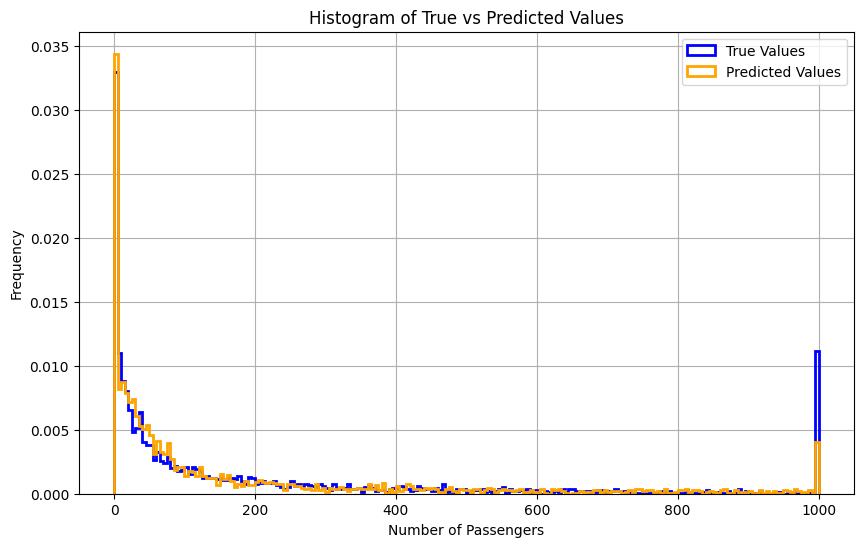

In [342]:
plt.figure(figsize=(10, 6))
plt.hist(y_true_test, bins=200, histtype='step', linewidth=2, color='blue', label='True Values', density=True)
plt.hist(y_pred_test, bins=200, histtype='step', linewidth=2, color='orange', label='Predicted Values', density=True)
plt.title("Histogram of True vs Predicted Values")
plt.xlabel("Number of Passengers")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.show()

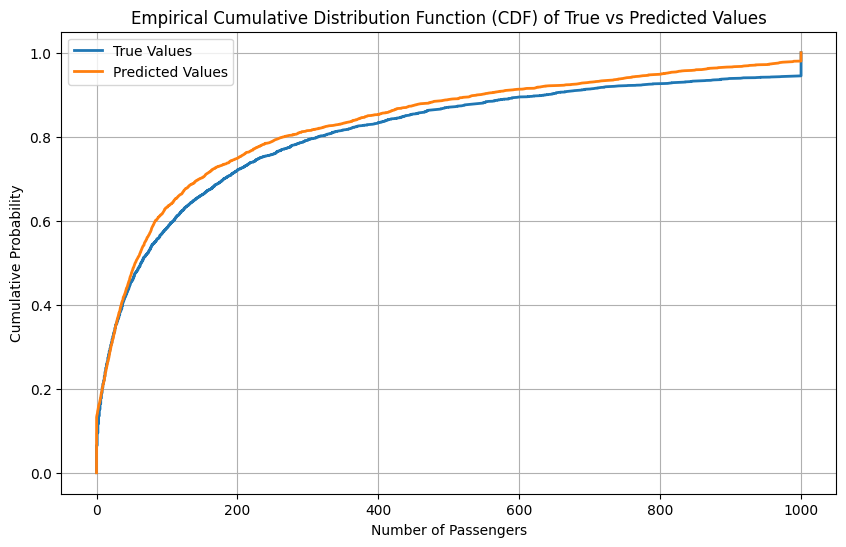

In [343]:
plt.figure(figsize=(10, 6))
plt.plot(np.sort(y_true_test), np.linspace(0, 1, len(y_true_test), endpoint=False), label="True Values", linewidth=2)
plt.plot(np.sort(y_pred_test), np.linspace(0, 1, len(y_pred_test), endpoint=False), label="Predicted Values", linewidth=2)
plt.title("Empirical Cumulative Distribution Function (CDF) of True vs Predicted Values")
plt.xlabel("Number of Passengers")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid()
plt.show()